# Interesting Cases with Null Values

This cookbook explores specific scenarios you may encounter when synthesizing data that has missing values. Each section is self-contained — feel free to jump to the section that is most relevant to your case.

**Prerequisite:** Familiarity with SDV's basic null handling. If you're new to generating synthetic data from datasets with nulls, start with the *How to Generate Synthetic Data When Your Data Has Null Values* cookbook.

## Setup

We'll load a demo dataset and fit a default synthesizer that we can reference throughout the notebook.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

from sdv.datasets.demo import download_demo
from sdv.single_table import GaussianCopulaSynthesizer
from rdt.transformers.pii import AnonymizedFaker

data, metadata = download_demo(
    modality="single_table", dataset_name="null_values_demo_dataset"
)


def phone_transformer():
    return {
        "customer_phone": AnonymizedFaker(
            provider_name="phone_number", function_name="phone_number"
        )
    }


synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.auto_assign_transformers(data)
synthesizer.update_transformers(phone_transformer())
synthesizer.fit(data)
synthetic_data = synthesizer.sample(num_rows=2000)

print(f"Dataset: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Columns with nulls: {data.isnull().any().sum()}")

Dataset: 2000 rows, 17 columns
Columns with nulls: 13


## How different synthesizers handle null values

SDV offers several single-table synthesizers: `GaussianCopulaSynthesizer`, `CTGANSynthesizer`, `TVAESynthesizer`, and `CopulaGANSynthesizer`. Since null handling happens in the preprocessing layer — before the data reaches the synthesizer — all of them share a common preprocessing pipeline for null handling.

Let's verify by comparing GaussianCopula and CTGAN on our dataset:

In [3]:
from sdv.single_table import CTGANSynthesizer

ctgan = CTGANSynthesizer(metadata, epochs=5)
ctgan.auto_assign_transformers(data)
ctgan.update_transformers(phone_transformer())
ctgan.fit(data)
ctgan_synthetic = ctgan.sample(num_rows=2000)

null_compare = pd.DataFrame(
    {
        "Real": data.isnull().mean().round(3),
        "GaussianCopula": synthetic_data.isnull().mean().round(3),
        "CTGAN": ctgan_synthetic.isnull().mean().round(3),
    }
)
null_compare[null_compare["Real"] > 0]

,Real,GaussianCopula,CTGAN
customer_email,0.101,0.101,0.101
category,0.146,0.132,0.194
is_escalated,0.200,0.206,0.260
response_time_hours,0.049,0.044,0.044
resolution_time_hours,0.305,0.306,0.306
satisfaction_score,0.684,0.664,0.664
internal_notes_count,0.928,0.925,0.925
resolved_at,0.305,0.314,0.314
resolution_status,0.305,0.294,0.298
agent_name,0.078,0.078,0.078


The null rates are nearly identical across both synthesizers. The small differences come from the synthesizers' modeling approaches, not from how nulls are managed.

> **Key takeaway:** Your choice of synthesizer doesn't affect null handling. Pick the synthesizer based on your quality and performance needs.

## When null rates don't match: `from_column` distortion

When you use `missing_value_generation='from_column'`, the synthesizer needs to model a binary indicator — "is this value null or not?" — alongside all other columns. The `GaussianCopulaSynthesizer` models everything using continuous Gaussian distributions, which creates a fundamental mismatch: it's trying to represent a 0/1 signal with a bell curve. The result is that the synthesizer can produce null rates that are very different from the original data.

**How significant can the distortion be?**
Let's look at six columns with varying null ratios: 'response_time_hours', 'resolution_time_hours', 'satisfaction_score', 'internal_notes_count', 'num_reassignments', 'response_time_legacy'.

In [4]:
from rdt.transformers.numerical import FloatFormatter
from rdt.transformers.datetime import UnixTimestampEncoder

nullable_numerical = [
    "response_time_hours",
    "resolution_time_hours",
    "satisfaction_score",
    "internal_notes_count",
    "num_reassignments",
    "response_time_legacy",
]

fc_synthesizer = GaussianCopulaSynthesizer(metadata)
fc_synthesizer.auto_assign_transformers(data)
fc_synthesizer.update_transformers(phone_transformer())
fc_synthesizer.update_transformers(
    {
        col: FloatFormatter(
            missing_value_replacement="mean", missing_value_generation="from_column"
        )
        for col in nullable_numerical
    }
)
fc_synthesizer.update_transformers(
    {
        "resolved_at": UnixTimestampEncoder(missing_value_generation="from_column"),
    }
)
fc_synthesizer.fit(data)
synthetic_fc = fc_synthesizer.sample(num_rows=2000)

The numerical comparison across all nullable numerical columns:

| Column | Real | `random` (default) | `from_column` |
| --- | --- | --- | --- |
| `response_time_hours` | 4.9% | 4.5% | 100.0% |
| `resolution_time_hours` | 30.5% | 30.6% | 32.3% |
| `satisfaction_score` | 68.4% | 66.4% | 69.2% |
| `internal_notes_count` | 92.8% | 92.5% | 98.9% |
| `num_reassignments` | 19.5% | 19.2% | 20.5% |

`random` mode stays within ~2 percentage points of the real null rate everywhere. `from_column` is unpredictable — sometimes close to the real rate, sometimes wildly off, with `response_time_hours` blowing up to a synthetic null rate of 100%.

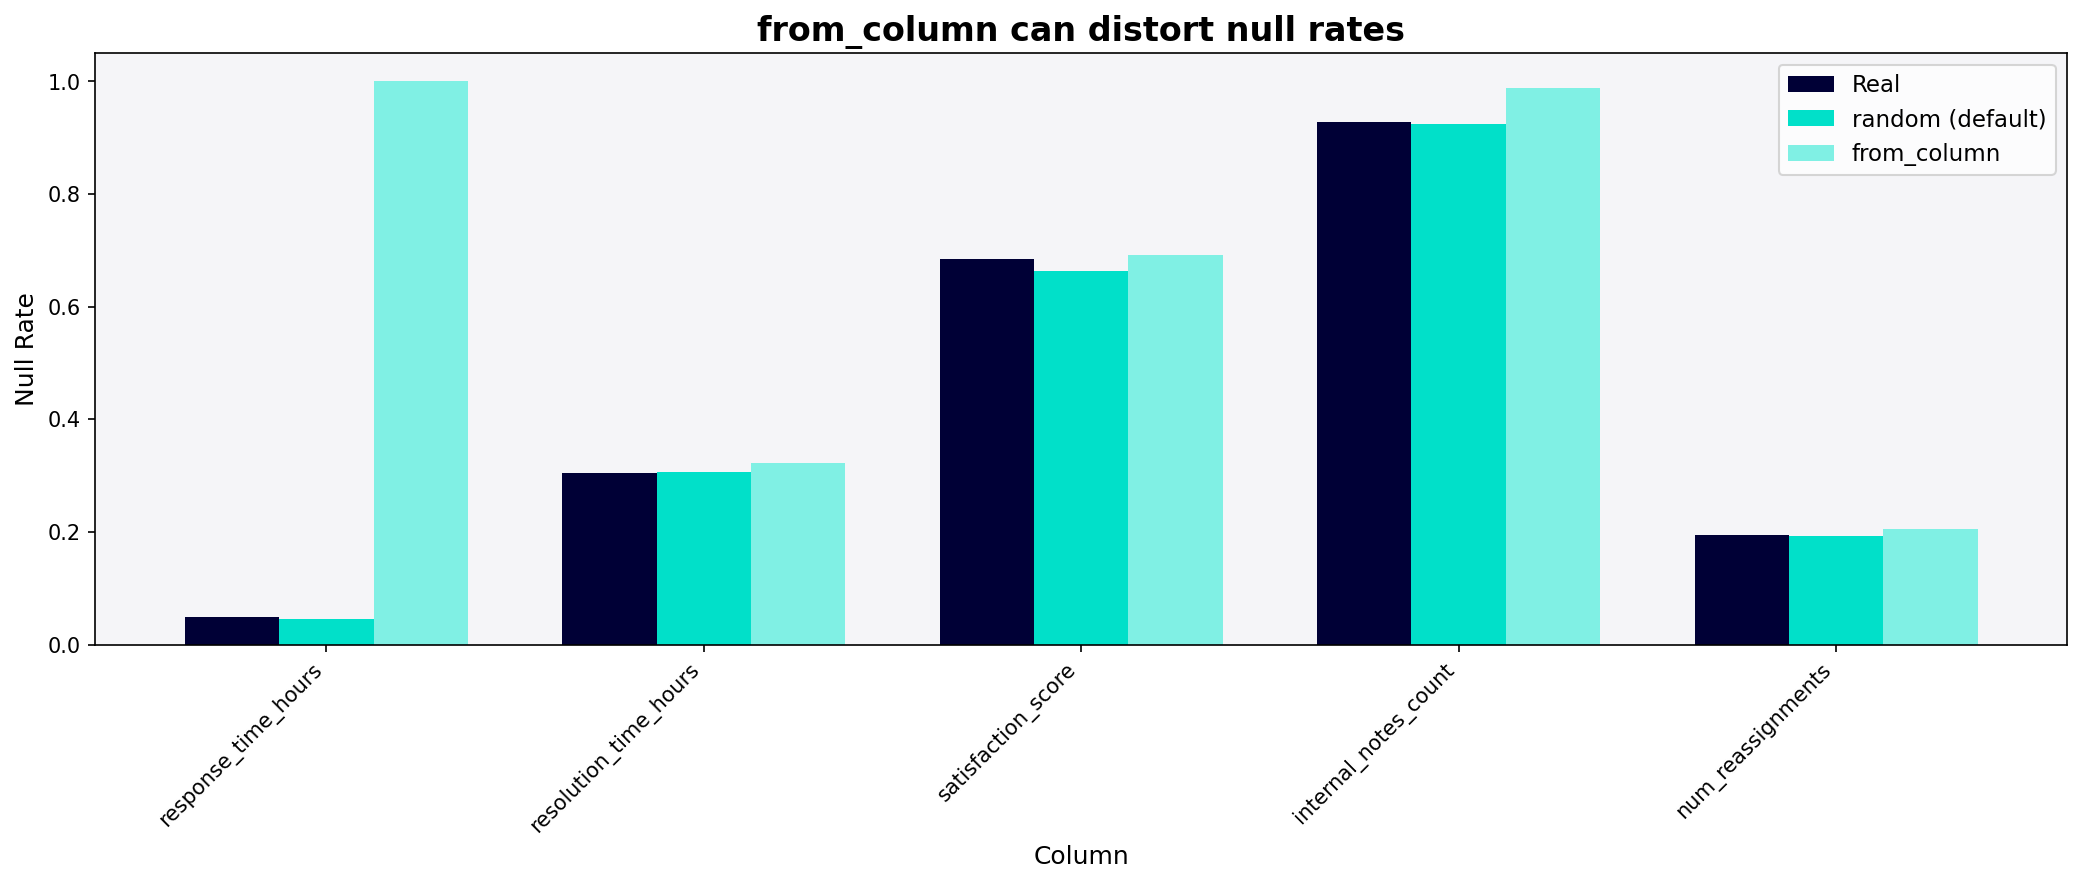

The `response_time_hours` column is the most dramatic example: it jumps from 4.9% null in the real data to 100% null with `'from_column'`. Meanwhile, the default `'random'` mode stays within 1% of the real rate.

The severity of the distortion depends on the original null rate. Columns near 50% null tend to be modeled more accurately, while columns at the extremes (very few nulls or very many) are most susceptible.

> **Key takeaway:** If you use `'from_column'` with GaussianCopula, always compare `data.isnull().mean()` against `synthetic_data.isnull().mean()` after sampling.

## How mean replacement affects synthetic data quality

Before the synthesizer trains, null values need to be replaced with actual numbers. The default strategy is `missing_value_replacement='mean'` — every null is filled with the column's mean value.

When the null rate is low, this rarely shows up in the output. But when a column has a very high null rate, most of the training data becomes the same value clustered at the mean. The synthesizer learns this artificial concentration as a real pattern and reproduces it as a tall spike at the mean of the column.

A stark example is `internal_notes_count`, which is null in about 93% of rows. After mean replacement, nearly every training value is the same number — and the synthesizer treats that as the column's true center.

**What does this look like?**

The mean of `internal_notes_count` is roughly 11.7 across the 2,000 rows in our dataset. With ~93% of those rows null, mean replacement turns about 1,856 training values into the same number — 11.7. By the time the synthesizer sees the column, almost the entire distribution looks like a single point at the mean.

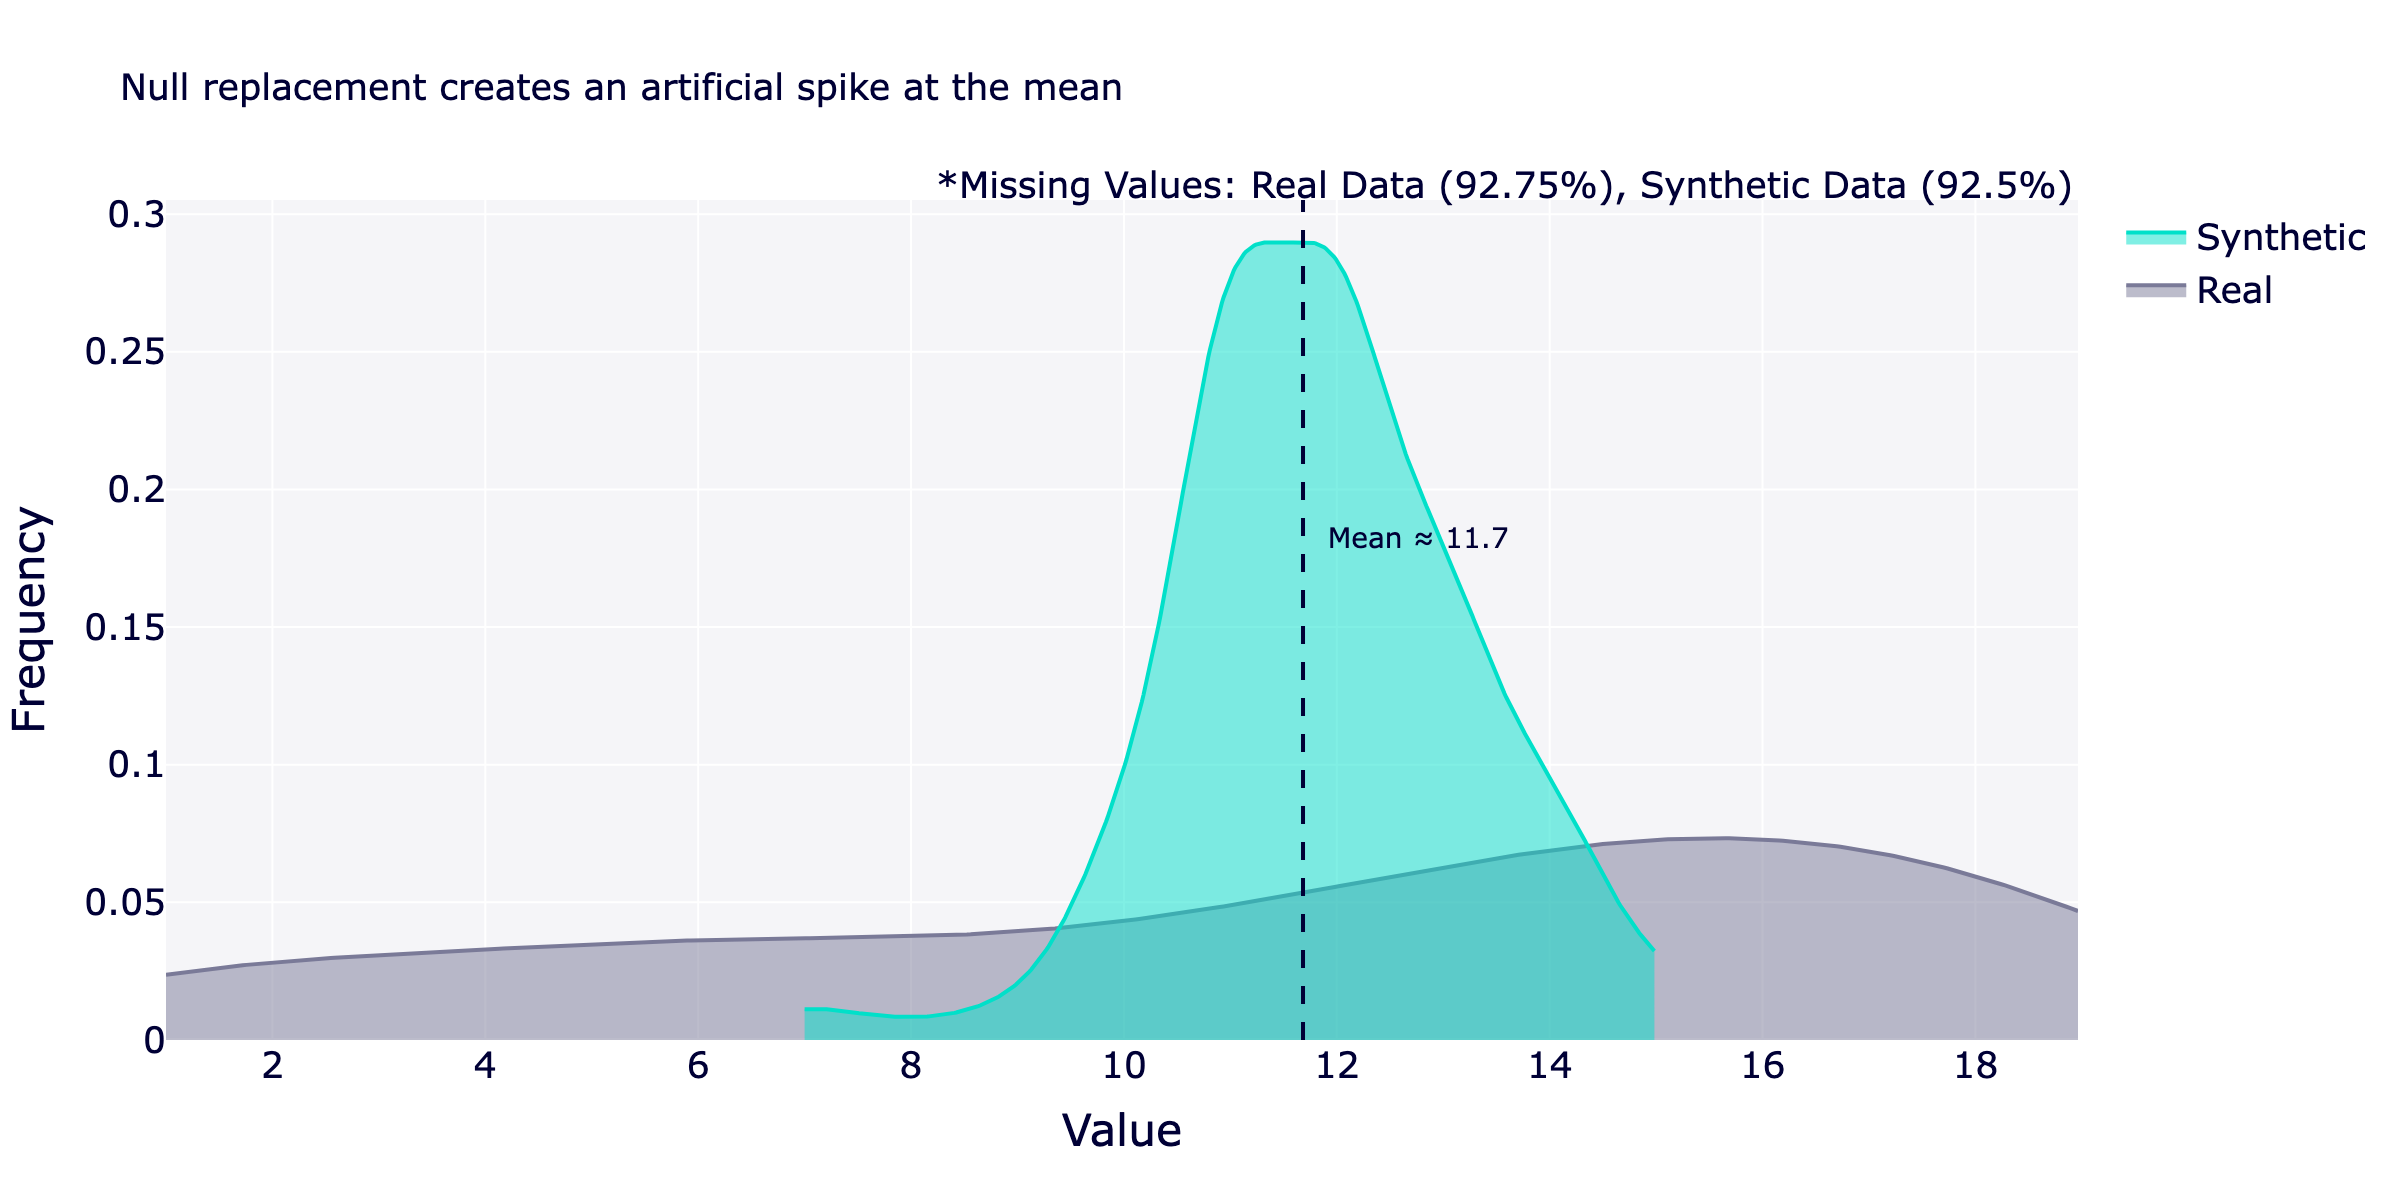

Two artifacts are visible in the plot. The first is the tall spike right at the mean (~11.7) — the dashed line marks where the spike lands. The second is the much narrower synthetic range: most synthetic values fall between 7 and 15, while real values span 1 to 19. Mean replacement doesn't just bias the location of the column — it collapses the spread too. With 93% of training values identical, the synthesizer learned a tight Gaussian centered on the mean and never recovers the original distribution's tails.

The alternative is to update the synthesizer's transformers with `missing_value_replacement='random'`, which fills nulls with a value chosen uniformly at random from the column's min/max range:

```python
FloatFormatter(missing_value_replacement='random', missing_value_generation='random')
```

This avoids the artificial spike and generally produces better results for columns with many nulls.

## What `None` mode does (and doesn't do) across column types

Setting `missing_value_generation=None` tells SDV not to recreate nulls for a given column. This works well for numerical and datetime columns — the synthetic output will have zero missing values. But not all column types respect this setting equally.

**Which columns still have nulls after using `None` mode?**

In [5]:
none_synth = GaussianCopulaSynthesizer(metadata)
none_synth.auto_assign_transformers(data)
none_synth.update_transformers(phone_transformer())
none_synth.update_transformers(
    {
        col: FloatFormatter(
            missing_value_replacement="mean", missing_value_generation=None
        )
        for col in nullable_numerical
    }
)
none_synth.update_transformers(
    {
        "resolved_at": UnixTimestampEncoder(missing_value_generation=None),
    }
)
none_synth.fit(data)
synthetic_none = none_synth.sample(num_rows=2000)

none_comparison = pd.DataFrame(
    {
        "Real": data.isnull().mean().round(3),
        "None mode": synthetic_none.isnull().mean().round(3),
    }
)
none_comparison[none_comparison["Real"] > 0]

,Real,None mode
customer_email,0.101,0.101
category,0.146,0.132
is_escalated,0.200,0.206
response_time_hours,0.049,0.000
resolution_time_hours,0.305,0.000
satisfaction_score,0.684,0.000
internal_notes_count,0.928,0.000
resolved_at,0.305,0.000
resolution_status,0.305,0.294
agent_name,0.078,0.078


Several columns still show nulls despite `None` mode:

- **Categorical columns** (`category`, `is_escalated`, `resolution_status`) — treat null as just another category value, so null is part of their learned distribution regardless
- **PII columns** (`customer_email`, `agent_name`, `customer_phone`) — regenerate values using Faker and independently reintroduce nulls at the original rate
- **All-null columns** (`customer_notes`) — there's nothing to generate, so the column stays 100% null

> **Key takeaway:** `None` mode works for numerical and datetime columns but does not affect categorical, PII, or all-null columns. To get zero nulls across all columns, clean your source data before fitting.

## Columns that are entirely null

The `customer_notes` column in our dataset is 100% null — every value is missing. SDV handles this correctly: the synthetic output is also 100% null, since null is the only known "category" and everything maps back to null.

This is expected behavior, but it means the synthesizer is doing unnecessary work. If you don't need the column in your synthetic output, drop it from the data before fitting.

The numbers confirm it: `customer_notes` has a real null rate of 100% (all 2,000 values are missing) and a synthetic null rate of 100%. The column has 0 unique non-null values — there's nothing for the synthesizer to learn from and nothing to reproduce.

## Preserving nullable integer types (`Int64`)

When a pandas integer column contains null values, pandas automatically converts it to `float64` — because the standard `int64` type can't represent `NaN`. This means values display as `1.0` instead of `1`, and nulls appear as `NaN` instead of `<NA>`.

Pandas offers a nullable integer type, `Int64` (with a capital I), that avoids this conversion. SDV can work with `Int64`, but it requires three steps to round-trip correctly.

**Can SDV preserve `Int64`?**

In [6]:
print(f"Before — dtype: {synthetic_data['num_reassignments'].dtype}")
synthetic_data[["ticket_id", "num_reassignments"]].head(10)

Before — dtype: float64


,ticket_id,num_reassignments
0,TKT-01139,5.0
1,TKT-01248,5.0
2,TKT-00488,3.0
3,TKT-01235,2.0
4,TKT-00448,4.0
5,TKT-00427,5.0
6,TKT-00001,3.0
7,TKT-00034,4.0
8,TKT-00525,5.0
9,TKT-01945,NaN


The dtype is `float64` and what should be `1` displays as `1.0`. To preserve the integer type, cast the source column to pandas' nullable `Int64`, update the metadata, and re-fit the synthesizer:

In [7]:
data["num_reassignments"] = data["num_reassignments"].astype("Int64")
metadata.update_column("num_reassignments", computer_representation="Int64")

int64_synth = GaussianCopulaSynthesizer(metadata)
int64_synth.auto_assign_transformers(data)
int64_synth.update_transformers(phone_transformer())
int64_synth.fit(data)
int64_synthetic_data = int64_synth.sample(num_rows=500)

print(f"After — dtype: {int64_synthetic_data['num_reassignments'].dtype}")
int64_synthetic_data[["ticket_id", "num_reassignments"]].head(10)

After — dtype: Int64


,ticket_id,num_reassignments
0,TKT-00122,5
1,TKT-00163,5
2,TKT-00310,3
3,TKT-00006,2
4,TKT-00382,4
5,TKT-00312,5
6,TKT-00239,3
7,TKT-00069,4
8,TKT-00212,<NA>
9,TKT-00157,<NA>


To preserve nullable integers, you need all three steps: (1) cast the source column to `Int64`, (2) set `computer_representation='Int64'` in the metadata, and (3) re-fit the synthesizer. Without all three, integers degrade to `float64`.

This matters if downstream systems expect integer types or if you're comparing data schemas between real and synthetic data.

## Conclusion

These edge cases are good to know about but are rarely blockers. SDV's default null handling works well for most datasets — the `'random'` mode preserves null rates accurately and requires no configuration.

When something unexpected happens with nulls in your synthetic data, check back here: whether it's `from_column` distorting rates, `None` mode not applying to all column types, or integer columns losing their dtype, the fix is usually a small configuration change.